<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/AnomalyDetection/AnomalyDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Elliptic envelope
Take multiple random samples and label each point in each sample as present, not present or outlier(using IQR). if A point appears as outlier in mjority of sample it is considered as outlier.

It is a costly algo from computation point of view and works only on unimode normally distributed data.

In [34]:
!gdown 1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg

Downloading...
From: https://drive.google.com/uc?id=1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg
To: /content/AnomalyDetection.csv
100% 33.0k/33.0k [00:00<00:00, 75.3MB/s]


In [35]:
import pandas as pd
df = pd.read_csv("AnomalyDetection.csv")

In [36]:
df.head()

,Mileage,Price
0,54.282388,67.967708
1,17.331911,70.023637
2,36.548113,68.080455
3,42.567541,71.058755
4,5.608853,57.822432


In [37]:
df.shape

(908, 2)

In [38]:
df.describe()

,Mileage,Price
count,908.000000,908.000000
mean,45.869736,77.555036
std,30.598219,19.275677
min,1.398964,20.000000
25%,25.415487,64.435773
50%,34.599453,73.550501
75%,49.862529,88.939217
max,128.604249,141.201890


Text(0, 0.5, 'Price')

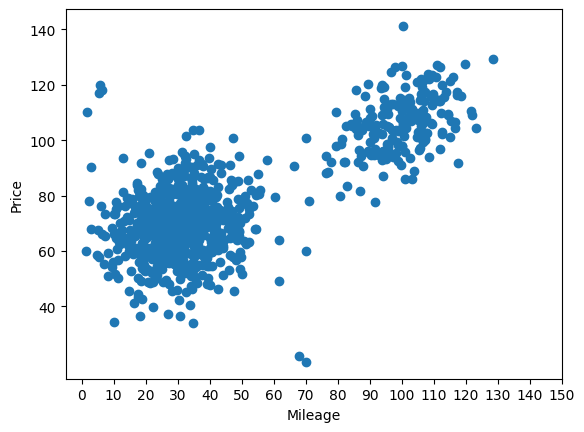

In [39]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(df.Mileage, df.Price)
plt.yticks(np.arange(40,160,20))
plt.xticks(np.arange(0,160,10))
plt.xlabel('Mileage')
plt.ylabel('Price')

In [40]:
from sklearn.covariance import EllipticEnvelope
elenvlp = EllipticEnvelope(contamination=0.025, random_state=1)
pred = elenvlp.fit_predict(df)
pred.shape

(908,)

In [41]:
unique_pred_values = np.unique(pred)
print(unique_pred_values)

[-1  1]


In [42]:
df["is_outliers_ee"] = pred
df.head()

,Mileage,Price,is_outliers_ee
0,54.282388,67.967708,1
1,17.331911,70.023637,1
2,36.548113,68.080455,1
3,42.567541,71.058755,1
4,5.608853,57.822432,1


In [43]:
df[df["is_outliers_ee"]==-1].shape

(23, 3)

#227 samples are outlier out of 908

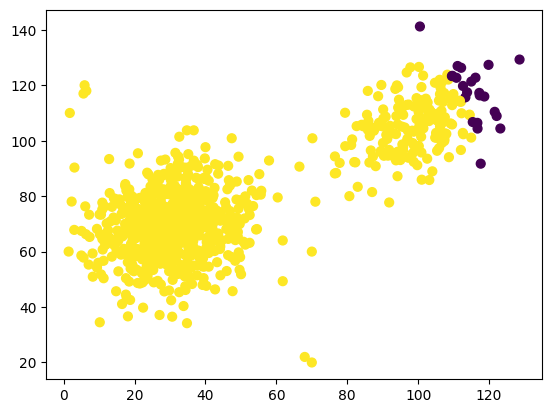

In [44]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outliers_ee'])

#Use the same data and do Isolation forest algorithm


In [45]:
from sklearn.ensemble import IsolationForest
isf = IsolationForest(random_state=0, contamination=0.025).fit_predict(df.iloc[:,:-1])
df['is_outlier_if'] = isf

In [46]:
df.head(5)

,Mileage,Price,is_outliers_ee,is_outlier_if
0,54.282388,67.967708,1,1
1,17.331911,70.023637,1,1
2,36.548113,68.080455,1,1
3,42.567541,71.058755,1,1
4,5.608853,57.822432,1,1


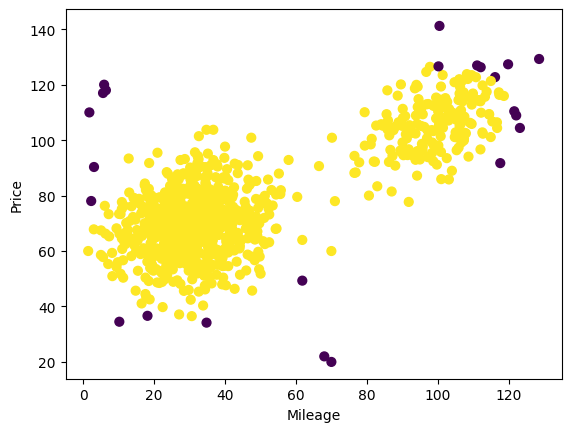

In [47]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_if'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

#Use the same data and do LocalOutlierFactor algorithm


In [48]:
from sklearn.neighbors import LocalOutlierFactor
local_out = LocalOutlierFactor(n_neighbors=20, contamination=0.025).fit_predict(df)
df['is_outlier_lof'] = local_out

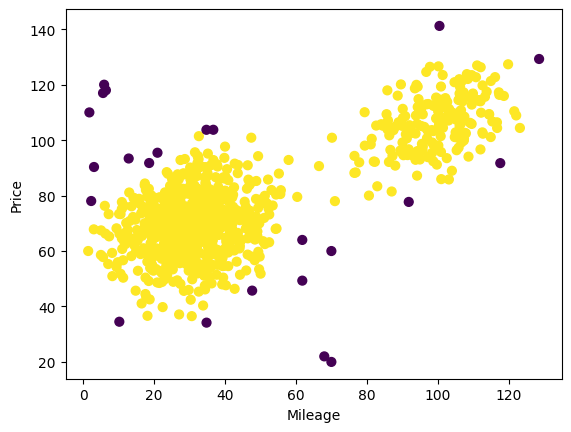

In [49]:
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_lof'])
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()